
# Lec - 11: INFO 376 — Content-Based Recommender Systems

> This notebook is designed to *teach by doing*. We build a content-based recommender from scratch using a small, manual dataset so every step is transparent and interpretable.

### What you'll learn
1. Representing items (TF–IDF, metadata encodings, numeric scaling, truncated SVD "semantic" space)  
2. Building a user profile (weights, time decay, session vs long-term)  
3. Similarity and ranking (cosine, filtering, diversity hints)  
4. Learning-based enhancements (logistic regression, decision tree, gradient boosting)  
5. Clustering for scale and insight (K-Means, Agglomerative)  
6. Adaptation over time (incremental updates, drift)  
7. Explainability (feature contributions, "why" an item was recommended)


In [3]:

# Core libs
import math
import json
import string
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

# Modeling / vectorization
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import train_test_split

# Plotting (matplotlib only; no seaborn)
import matplotlib.pyplot as plt

# For pretty display of DataFrames in some environments
pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 120)



## 1. A Manual Toy Dataset (Movies)

Let's handcraft a small dataset so that **every dimension is interpretable**.  
Each movie has:
- `title`
- `plot` (short synopsis text)
- `genres` (multi-label)
- `director` (categorical)
- `year` (numeric)
- `runtime_min` (numeric)
- `avg_rating` (numeric 1–5, as a weak popularity/quality proxy)
- `tags` (user-generated keywords)

We also create a **synthetic history** for one user, so we can build a profile and recommend new movies.

In [4]:
movies = [
    {
        "title": "Dream Heist",
        "plot": (
            "A skilled team of specialists enters shared dreams to steal guarded ideas. "
            "Inside each layered dream, time moves differently, and memory bends between imagination and reality. "
            "As the heist deepens, the dreamers lose track of whose memories they are living, risking their own subconscious collapse."
        ),
        "genres": ["Sci-Fi", "Thriller"],
        "director": "C. Nolan",
        "year": 2010,
        "runtime_min": 148,
        "avg_rating": 4.6
    },
    {
        "title": "Mind Maze",
        "plot": (
            "A reclusive puzzle designer builds a virtual maze from fragments of dreams and memories. "
            "Players trapped inside must solve emotional riddles that test logic and humanity. "
            "Each choice reshapes the maze, blurring the line between human memory and machine thought."
        ),
        "genres": ["Thriller", "Mystery"],
        "director": "A. Proyas",
        "year": 2016,
        "runtime_min": 112,
        "avg_rating": 4.2
    },
    {
        "title": "Subconscious Plan",
        "plot": (
            "Elite agents engineer a plan to plant a concept deep in the subconscious mind of a CEO. "
            "Through crafted dreams, they weave stories that alter his perception of memory and time. "
            "But manipulating another’s subconscious has consequences that echo through their own dreams."
        ),
        "genres": ["Sci-Fi", "Thriller"],
        "director": "C. Nolan",
        "year": 2012,
        "runtime_min": 141,
        "avg_rating": 4.4
    },
    {
        "title": "Romantic Holiday",
        "plot": (
            "Two travelers meet on a quiet island and fall into a love that feels timeless. "
            "Their days blend into dreams as they rediscover the beauty of memory and presence. "
            "But when time pulls them apart, each carries the other in heart and dream."
        ),
        "genres": ["Romance", "Comedy"],
        "director": "N. Ephron",
        "year": 2001,
        "runtime_min": 101,
        "avg_rating": 3.8
    },
    {
        "title": "Galactic Voyage",
        "plot": (
            "A space crew embarks on a desperate voyage to save a dying colony orbiting a collapsing star. "
            "They dream of home as they navigate galaxies filled with storms, black holes, and forgotten memories. "
            "Every moment of delay means another life lost to time and cosmic decay."
        ),
        "genres": ["Sci-Fi", "Adventure"],
        "director": "R. Scott",
        "year": 2018,
        "runtime_min": 129,
        "avg_rating": 4.1
    },
    {
        "title": "Quiet Café",
        "plot": (
            "In a small town café, a barista listens to customers’ stories of love, loss, and time passing. "
            "Each cup served holds a memory, each quiet moment a dream left unfinished. "
            "Through stillness, the barista learns that connection lives in silence as much as in words."
        ),
        "genres": ["Drama", "Slice-of-Life"],
        "director": "K. Kore-eda",
        "year": 2015,
        "runtime_min": 95,
        "avg_rating": 4.0
    },
    {
        "title": "Space Orchard",
        "plot": (
            "Farmers cultivate orchards aboard an orbital station circling Earth. "
            "Balancing work, family, and the vast loneliness of space, they fight to preserve their dream of life among the stars. "
            "Cosmic storms test their roots, both literal and emotional."
        ),
        "genres": ["Sci-Fi", "Drama"],
        "director": "D. Villeneuve",
        "year": 2021,
        "runtime_min": 124,
        "avg_rating": 4.3
    },
    {
        "title": "Campus Capers",
        "plot": (
            "At a lively university campus, a misfit trio stages elaborate pranks to escape the boredom of routine. "
            "Their chaos sparks unlikely friendships and memories that will last long after graduation. "
            "But when their final prank turns serious, they must face the consequences of growing up."
        ),
        "genres": ["Comedy"],
        "director": "P. Feig",
        "year": 2009,
        "runtime_min": 104,
        "avg_rating": 3.6
    },
    {
        "title": "Time Ledger",
        "plot": (
            "An accountant discovers a mysterious ledger that allows him to rewind time by rewriting events. "
            "Each entry changes the memories of everyone around him, including his own. "
            "As dreams and reality merge, he must choose between correcting the past or living with its consequences."
        ),
        "genres": ["Sci-Fi", "Mystery"],
        "director": "S. Soderbergh",
        "year": 2013,
        "runtime_min": 118,
        "avg_rating": 4.0
    },
    {
        "title": "Ocean’s Lullaby",
        "plot": (
            "A marine biologist returns to her coastal hometown to protect a coral reef threatened by industry. "
            "While reviving the reef, she reconnects with old memories and a lost love. "
            "The rhythm of the ocean mirrors her dreams of healing, both for the sea and for herself."
        ),
        "genres": ["Drama", "Romance"],
        "director": "C. Zhao",
        "year": 2019,
        "runtime_min": 107,
        "avg_rating": 4.1
    }
]

import pandas as pd
df = pd.DataFrame(movies)
df


,title,plot,genres,director,year,runtime_min,avg_rating
0,Dream Heist,"A skilled team of specialists enters shared dreams to steal guarded ideas. Inside each layered dream, time moves dif...","[Sci-Fi, Thriller]",C. Nolan,2010,148,4.6
1,Mind Maze,A reclusive puzzle designer builds a virtual maze from fragments of dreams and memories. Players trapped inside must...,"[Thriller, Mystery]",A. Proyas,2016,112,4.2
2,Subconscious Plan,"Elite agents engineer a plan to plant a concept deep in the subconscious mind of a CEO. Through crafted dreams, they...","[Sci-Fi, Thriller]",C. Nolan,2012,141,4.4
3,Romantic Holiday,Two travelers meet on a quiet island and fall into a love that feels timeless. Their days blend into dreams as they ...,"[Romance, Comedy]",N. Ephron,2001,101,3.8
4,Galactic Voyage,A space crew embarks on a desperate voyage to save a dying colony orbiting a collapsing star. They dream of home as ...,"[Sci-Fi, Adventure]",R. Scott,2018,129,4.1
5,Quiet Café,"In a small town café, a barista listens to customers’ stories of love, loss, and time passing. Each cup served holds...","[Drama, Slice-of-Life]",K. Kore-eda,2015,95,4.0
6,Space Orchard,"Farmers cultivate orchards aboard an orbital station circling Earth. Balancing work, family, and the vast loneliness...","[Sci-Fi, Drama]",D. Villeneuve,2021,124,4.3
7,Campus Capers,"At a lively university campus, a misfit trio stages elaborate pranks to escape the boredom of routine. Their chaos s...",[Comedy],P. Feig,2009,104,3.6
8,Time Ledger,An accountant discovers a mysterious ledger that allows him to rewind time by rewriting events. Each entry changes t...,"[Sci-Fi, Mystery]",S. Soderbergh,2013,118,4.0
9,Ocean’s Lullaby,A marine biologist returns to her coastal hometown to protect a coral reef threatened by industry. While reviving th...,"[Drama, Romance]",C. Zhao,2019,107,4.1



## 2. Turning Plots into Vectors (TF–IDF)

We convert each plot into a sparse vector where each dimension corresponds to a term in our toy vocabulary.  
**TF** = how often a term appears in this plot; **IDF** = how rare the term is across all plots.  
Their product highlights words that are both frequent in a plot and distinctive in the corpus.


In [6]:

# Basic TF-IDF with simple preprocessing
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1,2),       # include unigrams + bigrams for more nuance (e.g., "dream", "dreams", "layered dreams")
    min_df=1
)
tfidf = vectorizer.fit_transform(df["plot"].values)
vocab = np.array(vectorizer.get_feature_names_out())

# Show TF-IDF top terms for a specific movie (try for other movies by changing movie_idx)
movie_idx = 2
row = tfidf[movie_idx].toarray().ravel()
top_idx = row.argsort()[::-1][:10]

top_terms = list(zip(vocab[top_idx], row[top_idx]))
pd.DataFrame(top_terms, columns=["term", "tfidf_weight"])


,term,tfidf_weight
0,subconscious,0.259396
1,dreams,0.163807
2,echo dreams,0.152570
3,subconscious consequences,0.152570
4,perception memory,0.152570
5,perception,0.152570
6,time manipulating,0.152570
7,manipulating subconscious,0.152570
8,deep subconscious,0.152570
9,ceo,0.152570



### Visualize the top TF–IDF terms for one movie

Interpretation: taller bars mean the model believes these words best define this movie compared to the rest of the catalog.


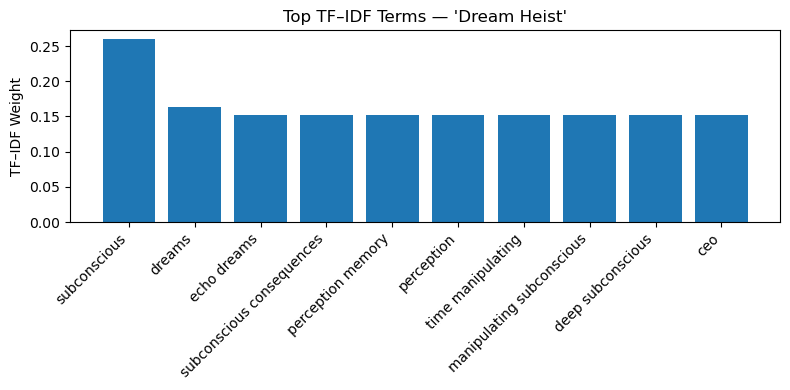

In [7]:

# Bar plot of top terms for the selected movie (matplotlib only, no specific colors)
terms = [t for t, w in top_terms]
weights = [w for t, w in top_terms]

plt.figure(figsize=(8,4))
plt.bar(terms, weights)
plt.xticks(rotation=45, ha="right")
plt.title("Top TF–IDF Terms — 'Dream Heist'")
plt.ylabel("TF–IDF Weight")
plt.tight_layout()
plt.show()



## 3. Structured Metadata Encoding

Content-based recommenders rarely rely on text *alone*.  
We add categorical and numeric signals:

- **Genres (multi-hot):** each genre is a binary dimension (1 if present).  
- **Director (one-hot):** captures stylistic influence.  
- **Year, Runtime, Avg Rating (numeric):** we will **scale** these for comparability.

We'll then **concatenate** these with the TF–IDF vectors to form a unified item representation.


In [8]:
# --- Genre multi-hot encoding ---

# 1. Collect all unique genres across the dataset.
#    Each movie has a list of genres (e.g., ["Sci-Fi", "Thriller"]),
#    so we flatten the lists and build a sorted set of all unique genre names.
all_genres = sorted({g for glist in df["genres"] for g in glist})

# 2. Create a mapping from genre name to its column index.
#    Example: {"Adventure": 0, "Comedy": 1, "Drama": 2, "Romance": 3, "Sci-Fi": 4, "Thriller": 5}
genre_to_idx = {g: i for i, g in enumerate(all_genres)}

# 3. Initialize an empty matrix (num_movies × num_genres),
#    filled with zeros. Each row represents a movie, and
#    each column represents a genre.
genre_matrix = np.zeros((len(df), len(all_genres)))

# 4. For every movie (row `r`), look at its genre list (`glist`).
#    For each genre `g` in that list, mark the corresponding column
#    position in the matrix as 1.0 — this is multi-hot encoding.
#    A "1" means the movie belongs to that genre.
for r, glist in enumerate(df["genres"]):
    for g in glist:
        genre_matrix[r, genre_to_idx[g]] = 1.0

# 5. Create column names for readability or for merging with a DataFrame.
#    This will produce names like: ["genre::Adventure", "genre::Comedy", "genre::Drama", ...]
genre_cols = [f"genre::{g}" for g in all_genres]

print("Genre Columns:", genre_cols)
print("Genre Matrix Shape:", genre_matrix.shape)

Genre Columns: ['genre::Adventure', 'genre::Comedy', 'genre::Drama', 'genre::Mystery', 'genre::Romance', 'genre::Sci-Fi', 'genre::Slice-of-Life', 'genre::Thriller']
Genre Matrix Shape: (10, 8)


In [9]:
# --- Director one-hot encoding ---

# 1. Extract a sorted list of all unique directors from the dataset.
#    Each movie has a single director (string), so we just use .unique() here.
#    Sorting ensures consistent column order every time the code runs.
directors = sorted(df["director"].unique())

# 2. Create a mapping from each director to its column index.
#    Example: {"A. Proyas": 0, "C. Nolan": 1, "C. Zhao": 2, ...}
dir_to_idx = {d: i for i, d in enumerate(directors)}

# 3. Initialize a zero matrix of shape (num_movies × num_directors).
#    Each row represents a movie, and each column represents one director.
#    We'll mark a '1' in the column corresponding to the movie’s director.
dir_matrix = np.zeros((len(df), len(directors)))

# 4. For every movie (row `r`), get its director `d`.
#    Use the mapping to find that director’s column index, and set it to 1.0.
#    This produces a one-hot encoded representation since each movie
#    has exactly one director.
for r, d in enumerate(df["director"]):
    dir_matrix[r, dir_to_idx[d]] = 1.0

# 5. Optionally, create descriptive column names for later merging with a DataFrame.
#    Columns will look like: ["director::A. Proyas", "director::C. Nolan", ...]
dir_cols = [f"director::{d}" for d in directors]

print("Director Columns:", dir_cols)
print("Director Matrix Shape:", dir_matrix.shape)


Director Columns: ['director::A. Proyas', 'director::C. Nolan', 'director::C. Zhao', 'director::D. Villeneuve', 'director::K. Kore-eda', 'director::N. Ephron', 'director::P. Feig', 'director::R. Scott', 'director::S. Soderbergh']
Director Matrix Shape: (10, 9)


In [10]:
# --- Numeric features (scaled) ---

# 1. Select the numeric columns from the dataframe.
#    These are continuous numerical attributes that can influence similarity
#    or downstream modeling — for example:
#       - "year"         → release year of the movie
#       - "runtime_min"  → duration in minutes
#       - "avg_rating"   → average viewer rating
#    Converting to float ensures they’re all numeric (no mixed dtypes).
numeric = df[["year", "runtime_min", "avg_rating"]].astype(float).values

# 2. Initialize a StandardScaler to normalize each numeric feature.
#    StandardScaler transforms each column to have:
#        mean = 0
#        standard deviation = 1
#    This prevents features with large numeric ranges (e.g., year ≈ 2000s)
#    from dominating smaller-range features (e.g., ratings ≈ 1–5).
scaler = StandardScaler()

# 3. Fit the scaler on the numeric data (compute mean & std)
#    and transform the same data to the standardized scale.
numeric_scaled = scaler.fit_transform(numeric)

# 4. Create prefixed column names to distinguish numeric features
#    when later concatenating with other feature sets (e.g., TF-IDF, genres, directors).
#    Example: ["num::year", "num::runtime_min", "num::avg_rating"]
num_cols = [f"num::{c}" for c in ["year", "runtime_min", "avg_rating"]]

print("Numeric Columns:", num_cols)
print("Numeric Matrix Shape:", numeric_scaled.shape)
print("First 5 Rows of Scaled Numeric Features:\n", numeric_scaled[:5])

Numeric Columns: ['num::year', 'num::runtime_min', 'num::avg_rating']
Numeric Matrix Shape: (10, 3)
First 5 Rows of Scaled Numeric Features:
 [[-0.61423497  1.81282545  1.79042103]
 [ 0.46970909 -0.35533788  0.32885284]
 [-0.25292028  1.39123813  1.05963694]
 [-2.24015106 -1.01783223 -1.13271535]
 [ 0.83102378  0.66851703 -0.0365392 ]]


In [11]:
# Show a preview table
preview = pd.DataFrame(
    np.hstack([genre_matrix, dir_matrix, numeric_scaled]),
    columns=genre_cols + dir_cols + num_cols
)
preview.head()


,genre::Adventure,genre::Comedy,genre::Drama,genre::Mystery,genre::Romance,genre::Sci-Fi,genre::Slice-of-Life,genre::Thriller,director::A. Proyas,director::C. Nolan,director::C. Zhao,director::D. Villeneuve,director::K. Kore-eda,director::N. Ephron,director::P. Feig,director::R. Scott,director::S. Soderbergh,num::year,num::runtime_min,num::avg_rating
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.614235,1.812825,1.790421
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.469709,-0.355338,0.328853
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.252920,1.391238,1.059637
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-2.240151,-1.017832,-1.132715
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.831024,0.668517,-0.036539



### Combine everything into one item vector

Concatenate:  
`item_vector = [ TF–IDF | Genres (multi-hot) | Director (one-hot) | Scaled Numerics ]`


In [12]:
from scipy.sparse import hstack, csr_matrix

# --- Combine text and metadata features into a single sparse item matrix ---

# 1. Convert dense metadata arrays (genres, directors, numeric features)
#    into a sparse CSR matrix.
#    - genre_matrix: multi-hot encoded (many 0s, few 1s)
#    - dir_matrix: one-hot encoded
#    - numeric_scaled: standardized continuous features
#
#    np.hstack() concatenates them horizontally
#    (feature-wise), producing a dense 2D NumPy array,
#    then wrap it with csr_matrix() to convert it to sparse format.
#    This keeps memory usage low and makes it compatible with TF-IDF.
meta_sparse = csr_matrix(np.hstack([genre_matrix, dir_matrix, numeric_scaled]))

# 2. Concatenate TF-IDF text features (already sparse)
#    with the metadata (now sparse) into a single item-feature matrix.
#    - `hstack` performs column-wise concatenation for sparse matrices.
#    - The resulting `item_matrix` represents each movie using:
#         [ TF-IDF features | genre one-hots | director one-hots | numeric features ]
item_matrix = hstack([tfidf, meta_sparse])  # final unified item representation

# 3. Inspect the final matrix shape.
#    The output should be:
#       (num_movies, num_tfidf_features + num_genres + num_directors + num_numeric_features)
#    Example: (10, 5000 + 6 + 7 + 3)
#    This confirms that each movie is now represented by a single high-dimensional vector.
item_matrix.shape


(10, 462)


## 4. Building a User Profile (Weighted + Time-Decay)

We'll try to  simulate a single user with the following **explicit ratings** and **timestamps** (days since "now").  
The profile is a **weighted average** of liked item vectors, where the weight can include:
- rating intensity (e.g., 5★ = 1.0, 4★ = 0.8, 3★ = 0.6)
- recency via exponential decay \(w \leftarrow w \times e^{-\lambda \Delta t}\)


In [17]:
# --- Build a synthetic user profile using rating- and time-weighted history ---

# Each tuple in the history represents:
#   (movie_title, user_rating, days_ago_watched)
# The idea: more recent + higher-rated items contribute more to the user's taste vector.
history = [
    ("Dream Heist", 5, 20),
    ("Mind Maze", 4, 200),
    ("Subconscious Plan", 4, 120),
    ("Galactic Voyage", 4, 10),
    ("Quiet Café", 3, 5)
]

# 1. Map each movie title to its row index in the item_matrix.
#    This lets us directly access its feature vector from the matrix.
title_to_idx = {t: i for i, t in enumerate(df["title"])}


# 2. Convert numeric user ratings into importance weights.
#    A simple heuristic mapping — higher ratings = higher weights.
#    Example: 5★ → 1.0, 4★ → 0.8, etc.
def rating_to_weight(r):
    return {5: 1.0, 4: 0.8, 3: 0.6, 2: 0.3, 1: 0.1}.get(int(r), 0.5)

In [19]:
# 3. Define a time-decay parameter (lambda).
#    Older interactions should contribute less to the profile.
#    Exponential decay: exp(-λ * days_ago)
#    Example: λ=0.005 → after ~200 days, weight drops by ~63%.
lam = 0.005  # time decay rate

weights = []   # store final weights per movie
vectors = []   # store the corresponding item feature vectors


# 4. Iterate through each movie in the user's history.
#    - Compute a combined weight = rating_weight × time_decay
#    - Retrieve that movie's feature vector from the item_matrix.
for title, rating, days in history:
    idx = title_to_idx[title]
    rating_weight = rating_to_weight(rating)
    time_decay = math.exp(-lam * days)
    w = rating_weight * time_decay

    weights.append(w)
    vectors.append(item_matrix[idx])  # sparse row vector

print("Weights:", weights)
print("Number of Vectors:", len(vectors))

Weights: [0.9048374180359595, 0.2943035529371539, 0.43904930887522114, 0.7609835396005713, 0.5851859472169996]
Number of Vectors: 5


In [20]:

# 5. Compute the weighted average of all movie feature vectors.
#    - Each vector is multiplied by its corresponding weight.
#    - Then we normalize by total weight to keep scale consistent.
#
#    Because item_matrix rows are sparse, we can multiply each vector
#    efficiently using .multiply(w) and sum them directly.
w_sum = sum(weights)
user_profile = sum(v.multiply(w) for v, w in zip(vectors, weights)) * (1.0 / w_sum)

# 6. Result:
#    `user_profile` is a single sparse row vector representing
#    the user's preferences — a weighted combination of all
#    the movies they’ve rated, decayed by time.
user_profile  # sparse 1 × n_features vector

<1x462 sparse matrix of type '<class 'numpy.float64'>'
	with 258 stored elements in Compressed Sparse Row format>


### Inspect the user profile's strongest content signals

We can peek into the TF–IDF vocabulary to see **which words** dominate the user's taste.  
For metadata, we can inspect the genre and director dimensions.


In [21]:
# --- Inspect top TF-IDF terms from the learned user profile ---

# 1. The full user_profile vector includes:
#    [ TF-IDF features | genre features | director features | numeric features ]
#    To focus only on textual preferences (semantic content),
#    we slice out the TF-IDF portion from the beginning of the vector.

tfidf_cols = len(vocab)  # number of columns corresponding to TF-IDF terms


# 2. Convert the sparse user_profile to a dense 1D NumPy array.
#    This makes it easier to sort and index into directly.
#    Note: for small datasets this is fine; for millions of features, keep it sparse.
user_profile_dense = user_profile.toarray().ravel()


# 3. Find indices of the top 10 highest-weight TF-IDF terms.
#    - `argsort()[::-1]` sorts weights in descending order.
#    - `[:tfidf_cols]` ensures we only consider the text feature range.
#    - These terms have the largest contribution in defining the user's interests.
top_tfidf_idx = user_profile_dense[:tfidf_cols].argsort()[::-1][:10]


# 4. Display a ranked DataFrame of the top terms and their weights.
#    - `vocab[top_tfidf_idx]` gives the actual words/phrases.
#    - `user_profile_dense[top_tfidf_idx]` gives their corresponding weights.
#    This reveals what textual concepts dominate the user’s profile
#    (e.g., “dream”, “memory”, “space”, “time”).
import pandas as pd
pd.DataFrame({
    "term": vocab[top_tfidf_idx],
    "weight": user_profile_dense[top_tfidf_idx]
})


,term,weight
0,subconscious,0.073747
1,time,0.067915
2,memory,0.062491
3,dream,0.061796
4,barista,0.054534
5,dreams,0.053905
6,moment,0.052880
7,memories,0.048562
8,inside,0.047200
9,stories,0.042260


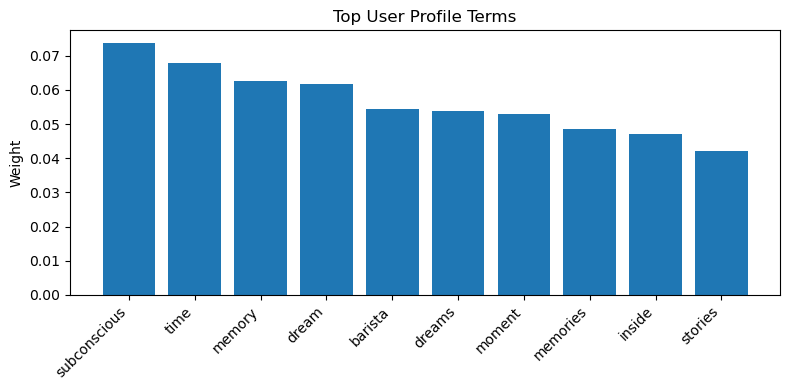

In [40]:

# Simple bar plot of top 10 user terms
terms = vocab[top_tfidf_idx]
weights = user_profile_dense[top_tfidf_idx]

plt.figure(figsize=(8,4))
plt.bar(terms, weights)
plt.title("Top User Profile Terms")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Weight")
plt.tight_layout()
plt.show()



## 5. Similarity and Ranking

Compute cosine similarity between the **user profile** and **every item**.  
Filter out already-consumed items, then sort to get top-N recommendations.


In [41]:
# --- Generate personalized recommendations using cosine similarity ---

from sklearn.metrics.pairwise import cosine_similarity

# 1. Compute cosine similarity between the user profile and all item vectors.
#    - Both user_profile and item_matrix live in the same feature space
#      (TF-IDF + metadata).
#    - cosine_similarity() returns values in [0, 1], where:
#         1 → perfectly similar
#         0 → orthogonal / unrelated
#
#    The result is a 1D array of similarity scores, one per movie.
sims = cosine_similarity(user_profile, item_matrix).ravel()

# 2. Attach the similarity scores to the movie dataframe for easy inspection.
#    Each movie now has an additional column "similarity"
#    representing how close it is to the user's inferred interests.
df["similarity"] = sims


# 3. Build a set of titles the user has already consumed.
#    We’ll filter these out so we only recommend unseen movies.
consumed = {t for (t, _, _) in history}


# 4. Filter out already-watched movies and create a candidate pool.
#    `.copy()` avoids SettingWithCopy warnings when sorting/modifying.
candidates = df[~df["title"].isin(consumed)].copy()


# 5. Sort remaining movies by similarity in descending order.
#    Higher cosine similarity → stronger match with user's profile.
candidates = candidates.sort_values("similarity", ascending=False)


# 6. Display top 5 recommendations with key metadata.
#    Shows each recommended movie’s title, genres, director, release year,
#    and its computed similarity score for interpretability.
candidates[["title", "genres", "director", "year", "similarity"]].head(5)


,title,genres,director,year,similarity
6,Space Orchard,"[Sci-Fi, Drama]",D. Villeneuve,2021,0.444228
8,Time Ledger,"[Sci-Fi, Mystery]",S. Soderbergh,2013,0.183250
9,Ocean’s Lullaby,"[Drama, Romance]",C. Zhao,2019,-0.035781
3,Romantic Holiday,"[Romance, Comedy]",N. Ephron,2001,-0.299586
7,Campus Capers,[Comedy],P. Feig,2009,-0.419517


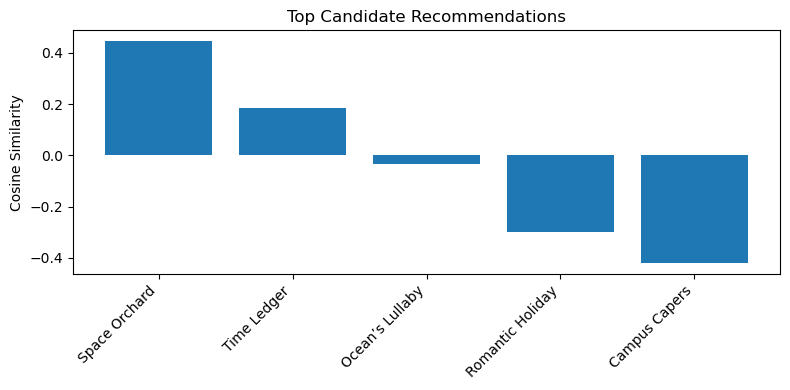

In [42]:

# Plot the similarity scores for top-7 candidates
top7 = candidates.head(7)
plt.figure(figsize=(8,4))
plt.bar(top7["title"], top7["similarity"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Cosine Similarity")
plt.title("Top Candidate Recommendations")
plt.tight_layout()
plt.show()



## 6. Adaptation Over Time (Drift Simulation)

We simulate a user who **shifts** from thrillers to drama/romance.  
Observe how the profile and recommendations change with **incremental updates**.


In [43]:
# --- Simulate user profile drift after new interactions ---

# 1. New user feedback arrives (recently watched movies).
#    These interactions indicate a potential shift in interests
#    — here toward Drama/Romance themes.
#    Each tuple: (movie_title, user_rating)
new_events = [
    ("Ocean’s Lullaby", 5),
    ("Romantic Holiday", 4)
]

# 2. Adaptation rate α controls how fast the profile shifts toward new preferences.
#    - α = 0.0 → no update (fully static profile)
#    - α = 1.0 → immediate overwrite (only new info kept)
#    - Here α = 0.35 means the new feedback contributes 35% of its weight,
#      and the old profile decays by 65% each step.
alpha = 0.35  # faster adaptation for demo visualization


# 3. Copy the previous (pre-drift) user profile to update incrementally.
u = user_profile.copy()

# 4. For each new event:
#    - Retrieve the movie's feature vector from item_matrix.
#    - Convert rating to a numeric importance weight.
#    - Update the user profile as a weighted moving average:
#         new_u = (1 - α) * old_u + (α * w) * item_vector
#    This formula makes the profile evolve continuously with each new rating.
for title, r in new_events:
    idx = title_to_idx[title]
    w = rating_to_weight(r)
    # Sparse operation — efficiently updates without densifying the vector
    u = u.multiply(1 - alpha) + item_matrix[idx].multiply(alpha * w)


# 5. Compute similarity scores before and after drift for all movies.
#    This lets us observe how recommendations change when the user
#    starts liking different genres (Drama/Romance in this example).
df["sim_before"] = sims
df["sim_after"] = cosine_similarity(u, item_matrix).ravel()


# 6. Filter out consumed titles and compare new vs. old similarity ranks.
#    Sorting by sim_after highlights which movies gained similarity after the update.
compare = df[~df["title"].isin(consumed)].copy()
compare = compare[["title", "genres", "sim_before", "sim_after"]]
compare = compare.sort_values("sim_after", ascending=False)

# 7. Show top 8 items for quick inspection.
#    Expect Drama/Romance films (e.g., “Ocean’s Lullaby”) to rise in rank.
compare.head(8)


,title,genres,sim_before,sim_after
3,Romantic Holiday,"[Romance, Comedy]",-0.299586,0.671989
9,Ocean’s Lullaby,"[Drama, Romance]",-0.035781,0.418014
7,Campus Capers,[Comedy],-0.419517,0.274106
8,Time Ledger,"[Sci-Fi, Mystery]",0.183250,0.186700
6,Space Orchard,"[Sci-Fi, Drama]",0.444228,0.010152


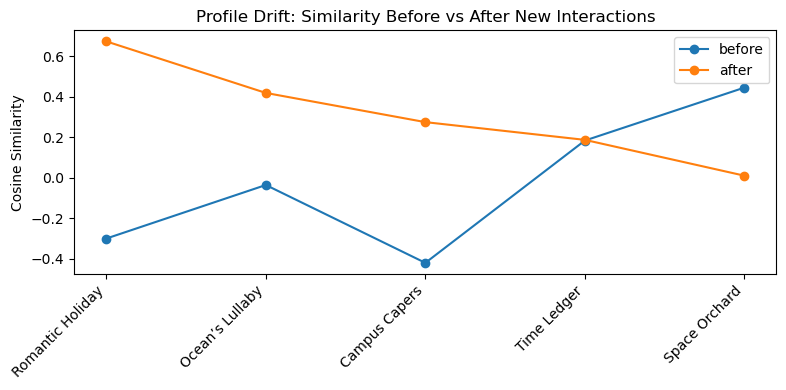

In [44]:

# Plot before vs after similarity for a few titles
top_titles = compare.head(8)["title"].tolist()
sub = compare.set_index("title").loc[top_titles]

plt.figure(figsize=(8,4))
x = np.arange(len(top_titles))
plt.plot(x, sub["sim_before"].values, marker="o", label="before")
plt.plot(x, sub["sim_after"].values, marker="o", label="after")
plt.xticks(x, top_titles, rotation=45, ha="right")
plt.ylabel("Cosine Similarity")
plt.title("Profile Drift: Similarity Before vs After New Interactions")
plt.legend()
plt.tight_layout()
plt.show()



## 10. Explainability: Why This Item?

We can explain similarity by showing **overlapping high-weight features** between the user profile and an item.  
Here, we display the top overlapping TF–IDF terms to justify the recommendation.


In [45]:
# --- Inspect term-level overlap between a user's profile and a candidate movie ---

def top_overlap_terms(user_vec_dense, item_vec, vocab, top_k=8):
    """
    Given a user profile vector and a specific movie vector,
    identify which TF-IDF terms contribute most to their similarity.

    Parameters
    ----------
    user_vec_dense : np.ndarray
        Dense 1D array representation of the user profile (1 × n_features).
        Typically `user_profile.toarray().ravel()`.
    item_vec : csr_matrix or np.ndarray
        Sparse row (from item_matrix) or dense vector for the chosen item.
    vocab : np.ndarray or list
        Vocabulary array mapping column indices → actual TF-IDF terms.
    top_k : int
        Number of top overlapping terms to display.

    Returns
    -------
    pd.DataFrame
        A ranked table showing:
            - term: shared feature term
            - user_w: user’s TF-IDF weight for that term
            - item_w: item’s TF-IDF weight for that term
            - overlap: product of weights (relative importance)
    """
    # 1. Convert the item vector to a dense 1D array if it’s sparse.
    #    We only need this for small slices (single items).
    item_dense = item_vec.toarray().ravel() if hasattr(item_vec, "toarray") else item_vec

    # 2. Extract only the TF-IDF portion of both user and item vectors.
    #    (Exclude genre, director, numeric features — we only want text semantics.)
    u_terms = user_vec_dense[:len(vocab)]
    i_terms = item_dense[:len(vocab)]

    # 3. Compute element-wise product of the two term-weight vectors.
    #    This represents "shared activation": high if both user and item
    #    strongly weight the same term → major contributor to cosine similarity.
    prod = u_terms * i_terms

    # 4. Get indices of top-k largest overlaps (descending order).
    idx = prod.argsort()[::-1][:top_k]

    # 5. Build a DataFrame showing the most influential shared terms.
    #    This helps explain *why* the model recommended this item.
    return pd.DataFrame({
        "term": vocab[idx],
        "user_w": u_terms[idx],
        "item_w": i_terms[idx],
        "overlap": prod[idx]
    })


# --- Apply the interpretability function ---

# 6. Pick the top recommended movie (highest cosine similarity before drift).
top_item_title = candidates.iloc[0]["title"]
top_item_idx = title_to_idx[top_item_title]

# 7. Get the top overlapping TF-IDF terms between the user and this movie.
#    These are the terms that most strongly "connect" the user's profile
#    to the item’s textual description — e.g., “dream”, “memory”, “time”.
overlap_df = top_overlap_terms(user_profile_dense, item_matrix[top_item_idx], vocab, top_k=8)

# 8. Display the results.
overlap_df


,term,user_w,item_w,overlap
0,dream,0.061796,0.086906,0.005370
1,storms,0.029701,0.124411,0.003695
2,space,0.029701,0.124411,0.003695
3,life,0.029701,0.124411,0.003695
4,cosmic,0.029701,0.124411,0.003695
5,emotional,0.011615,0.124411,0.001445
6,test,0.011615,0.124411,0.001445
7,work family,0.000000,0.146351,0.000000


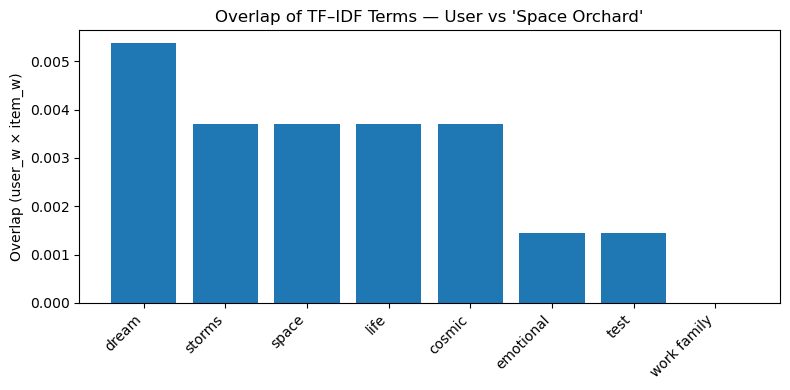

In [46]:

# Visualize overlap weights
plt.figure(figsize=(8,4))
plt.bar(overlap_df["term"], overlap_df["overlap"])
plt.title(f"Overlap of TF–IDF Terms — User vs '{top_item_title}'")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Overlap (user_w × item_w)")
plt.tight_layout()
plt.show()
